# **Haar Cascade Sınıflandırıcıları ile Yüz ve Göz Algılama**

####**Bu derste şunları öğreneceğiz:**
1. Yüzleri tespit etmek için bir Haarcascade Classifer kullanmak
2. Gözleri tespit etmek için bir Haarcascade Classifer kullanmak
3. Colab'da web kameranızdan yüzleri ve gözleri tespit etmek için bir Haarcascade Classifer kullanmak için


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()


## **Haarcascade Sınıflandırıcıları Kullanarak Basit Yüz Algılama**

### **Öncelikle, Nesne Algılama Nedir?**
<img src="nesne.png" width="400">

### **Nesne Algılama**, bir görüntüdeki nesneleri tek tek algılayıp sınıflandırma ve nesnenin alanı üzerinde bir sınırlayıcı kutu çizme işlemidir.

## **HAAR Sınıflandırıcılar**

Viola ve Jones tarafından 2001 yılında geliştirilmiştir.

Bir görüntüdeki nesneleri tanımlamak için bir dizi sınıflandırıcı (kaskad) kullanan bir nesne algılama yöntemidir. Bir tür nesneyi tanımlamak için eğitilirler, ancak birkaçını paralel olarak kullanabiliriz, örneğin gözleri ve yüzleri birlikte tespit edebiliriz. HAAR Sınıflandırıcıları çok sayıda pozitif görüntü (yani nesnenin bulunduğu görüntüler) ve negatif görüntü (yani nesnenin bulunmadığı görüntüler) kullanılarak eğitilir.

## Artıları ve Eksileri
### Artılar:
*Hızlı çalışır (gerçek zamanlı yüz algılamada uygundur).*
*OpenCV’de hazır modellerle kolayca kullanılabilir.*
### Eksiler:
*Karmaşık arka planlarda hatalar yapabilir.*
*Farklı ışık koşulları veya açı değişimlerinde performansı düşebilir.*
*Derin öğrenme tabanlı yöntemlere kıyasla daha az isabetlidir.*
## OpenCV'deki Popüler Haar Cascade Modelleri
1. Yüz Tespiti
2. Göz Tespiti
3. Plaka, Gülümseme ve Diğer Modeller


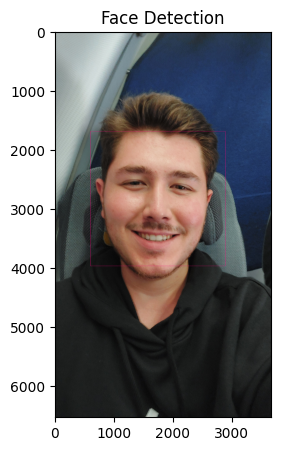

In [2]:
# OpenCV CascadeClassifier fonksiyonuna kullanacağımız filtreyi yüklüyoruz.
face_classifier = cv2.CascadeClassifier('../files/Haarcascades/haarcascade_frontalface_default.xml')

# Resmimizi yükleyin ve ardından gri tonlamaya dönüştürün
image = cv2.imread('../files/images/america21.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Sınıflandırıcımız tespit edilen yüzün ROI'sini bir tuple (demet) olarak döndürür
# Sol üst koordinatı ve sağ alt koordinatı depolar
# Python’da tuple, birden fazla değeri tek bir değişkende saklamaya yarayan, sıralı ve 
# değiştirilemez (immutable) bir veri yapısıdır.
faces = face_classifier.detectMultiScale(gray, scaleFactor = 1.3, minNeighbors = 5)

# Hiçbir yüz algılanmadığında, face_classifier boş bir tuple döndürür
if len(faces) == 0:
    print("No faces found")

# Yüzler dizimiz boyunca yineliyoruz ve bir dikdörtgen çiziyoruz
# yüzlerdeki her yüzün üzerinde
for (x,y,w,h) in faces:
    cv2.rectangle(image, (x,y), (x+w,y+h), (127,0,255), 2)

# (x, y, w, h) Nedir?
#x → Dikdörtgenin sol üst köşesinin yatay (horizontal) koordinatı
#y → Dikdörtgenin sol üst köşesinin dikey (vertical) koordinatı
#w → Dikdörtgenin genişliği (width)
#h → Dikdörtgenin yüksekliği (height)

imshow('Face Detection', image,5)

## **Haarcascade Sınıflandırıcıları Kullanarak Basit Göz ve Yüz Algılama**

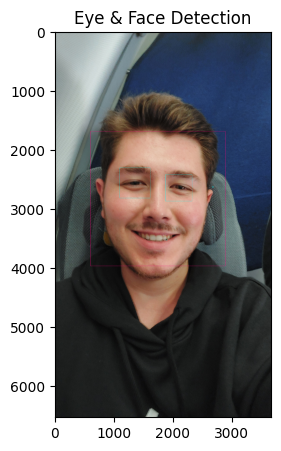

In [3]:
import numpy as np
import cv2

face_classifier = cv2.CascadeClassifier('../files/Haarcascades/haarcascade_frontalface_default.xml')
eye_classifier = cv2.CascadeClassifier('../files/Haarcascades/haarcascade_eye.xml')

img = cv2.imread('../files/images/america21.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_classifier.detectMultiScale(gray, 1.3, 5)

# Hiçbir yüz algılanmadığında, face_classifier boş bir tuple döndürür
if len(faces)==0:
    print("No Face Found")

for (x,y,w,h) in faces:
    cv2.rectangle(img,(x,y),(x+w,y+h),(127,0,255),2)
    roi_gray = gray[y:y+h, x:x+w] #Yüzün bulunduğu ilgili bölgeyi (ROI – Region of Interest) seçmek için kullanılır. 
    #Böylece göz tespiti tüm görüntüde değil, yalnızca yüz içinde yapılır.
    roi_color = img[y:y+h, x:x+w] 
    eyes = eye_classifier.detectMultiScale(roi_gray, 1.2, 3)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(255,255,0),2)

imshow('Eye & Face Detection',img,5)
# roi_color üzerinde dikdörtgen çizim yazılıyor ama img dosyasında da görünüyor ama nasıl
# Bu durumun nedeni, roi_color'un img dizisinin bir kopyası değil, onun bir dilimi (view) olmasıdır.
# Kopya ve Referans Arasındaki Fark
# Eğer bağımsız bir kopya almak isteseydik roi_color = img[y:y+h, x:x+w].copy() yazardık
# OpenCV’de roi_color gibi bir dilim üzerinde çizim yapmak, doğrudan ana görüntüyü de değiştirir.
# Bu da çıktıda tüm dikdörtgenlerin img üzerinde görünmesini sağlar.


### **Canlı yüz ve göz algılama yapmak için web kameranızı kullanın**

Bu yalnızca yerel bir makinede çalışır, Colab'da çalışmaz

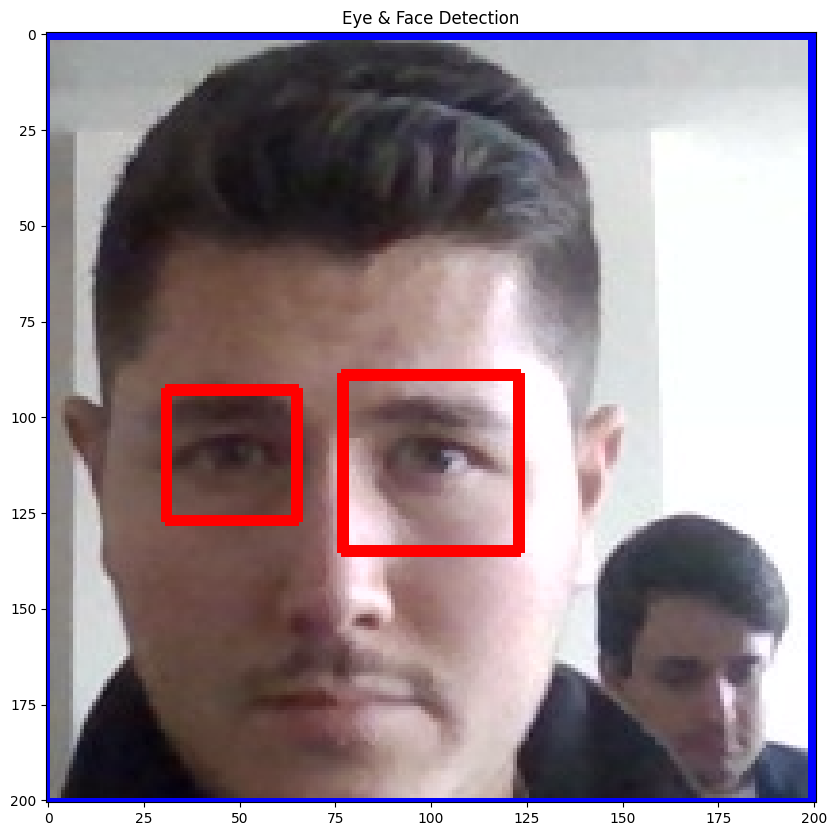

In [9]:
import cv2
import numpy as np

face_classifier = cv2.CascadeClassifier('../files/Haarcascades/haarcascade_frontalface_default.xml')
eye_classifier = cv2.CascadeClassifier('../files/Haarcascades/haarcascade_eye.xml')

def face_detector(img, size=0.5):
    # Convert image to grayscale
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    faces = face_classifier.detectMultiScale(gray, 1.3, 5)
    if len(faces) == 0:
        return img
    for (x,y,w,h) in faces:
        x = x - 50
        w = w + 50
        y = y - 50
        h = h + 50
        cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_classifier.detectMultiScale(roi_gray)

        for (ex,ey,ew,eh) in eyes:
            cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,0,255),2)
    
    roi_color = cv2.flip(roi_color,1)
    return roi_color
cap = cv2.VideoCapture(0)
#cv2.VideoCapture(0) satırındaki 0, bilgisayara bağlı olan kamera aygıtını belirtir.
#0: Varsayılan (genellikle dizüstü bilgisayarın dahili) kamerayı açar.
#1: Bilgisayara bağlı ilk harici kamerayı açar.
#2: Birden fazla kamera varsa ikinci harici kamerayı açar, ve bu şekilde devam eder.
ret, frame = cap.read()
cap.release()
img = face_detector(frame)
imshow('Eye & Face Detection',img)
